# Walmart Store Sales — Demand Forecasting (v2)

**AI Engineer Technical Assignment — NEUZENAI IT SOLUTIONS PVT LTD**

**Changelog from v1** (fixing issues found in code review):
- Best model is now **selected programmatically** from actual WMAE results — never hardcoded.
- Prophet/LSTM (aggregate-level, store+dept summed) are kept **out of the primary model comparison** against Linear Regression/Random Forest/LightGBM (store+dept level) since they solve a different-granularity problem — comparing them directly was an apples-to-oranges error in v1.
- Robustness testing now reports **both MAE and WMAE**, adds a **markdown-level** bucket in addition to holiday and store-type, matching the assignment's explicit requirement.
- Residual analysis extended to **per-store and per-department** breakdowns, not just vs-predicted/vs-time.
- Business interpretation is now **generated from the actual computed SHAP ranking**, not static template text.
- Fairness section reports **actual computed numbers**, not hypothetical guidance.
- **Test-set forecasting added**: a proper recursive/walk-forward pipeline builds lag/rolling features week-by-week for `test.csv` (which has no target to build lags from directly) and produces a Kaggle-format submission file.
- LSTM scaler is now **fit only on the training portion** of the series, not the full series — v1 had a preprocessing leakage bug.
- TimeSeriesSplit tuning now prints **per-fold scores**, not just the final best estimator.


## 1. Imports & Configuration


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

import lightgbm as lgb          # pip install lightgbm
from prophet import Prophet     # pip install prophet

import shap                     # pip install shap
from lime.lime_tabular import LimeTabularExplainer   # pip install lime

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)


## 2. Data Loading & Merging

Loads the four Kaggle files and merges into one modeling table. `stores.csv` is merged on `Store`; `features.csv` is merged on `Store` + `Date`.


In [4]:

stores = pd.read_csv(f'stores.csv')
train = pd.read_csv(f'train.csv', parse_dates=['Date'])
test = pd.read_csv(f'test.csv', parse_dates=['Date'])
features = pd.read_csv(f'features.csv', parse_dates=['Date'])

print('stores:', stores.shape, '| train:', train.shape, '| test:', test.shape, '| features:', features.shape)


stores: (45, 3) | train: (207323, 5) | test: (115064, 4) | features: (8190, 12)


In [5]:
# features.csv duplicates IsHoliday (already in train/test) — drop before merge to avoid a name clash
features_clean = features.drop(columns=['IsHoliday'])

def build_dataset(base_df):
    df = base_df.merge(stores, on='Store', how='left')
    df = df.merge(features_clean, on=['Store', 'Date'], how='left')
    return df

df_train = build_dataset(train)
df_test = build_dataset(test)
df_train.head()


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


## 3. Data Cleaning

- **MarkDown1–5**: missing means *no promotion ran that week* → fill with 0.
- **CPI / Unemployment**: slow-moving macro indicators, a few weeks near the test period are missing → forward-fill within each store.
- **Data quality finding**: a small number of `Weekly_Sales` values are **negative** (product returns exceeding sales in that store/department/week). These are kept — they're real transactions, not errors — but they matter: they inflate percentage-based metrics like MAPE, which is exactly why **WMAE/MAE, not MAPE, are the primary metrics** used throughout this notebook.


In [6]:
MARKDOWN_COLS = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

def clean_dataset(df):
    df = df.copy()
    df[MARKDOWN_COLS] = df[MARKDOWN_COLS].fillna(0)
    df[['CPI', 'Unemployment']] = (
        df.groupby('Store')[['CPI', 'Unemployment']]
          .transform(lambda s: s.ffill().bfill())
    )
    return df

df_train = clean_dataset(df_train)
df_test = clean_dataset(df_test)

print('Remaining NaNs (train):', df_train.isna().sum().sum())
print('Negative Weekly_Sales rows:', (df_train['Weekly_Sales'] < 0).sum(),
      f"({(df_train['Weekly_Sales'] < 0).mean()*100:.2f}% of rows)")


Remaining NaNs (train): 1
Negative Weekly_Sales rows: 607 (0.29% of rows)


## 4. Exploratory Data Analysis

Covers sales trends over time, store-type comparison, holiday impact, correlations, target distribution, **and department-level analysis** (added per review — v1 under-covered department trends relative to store/time trends).


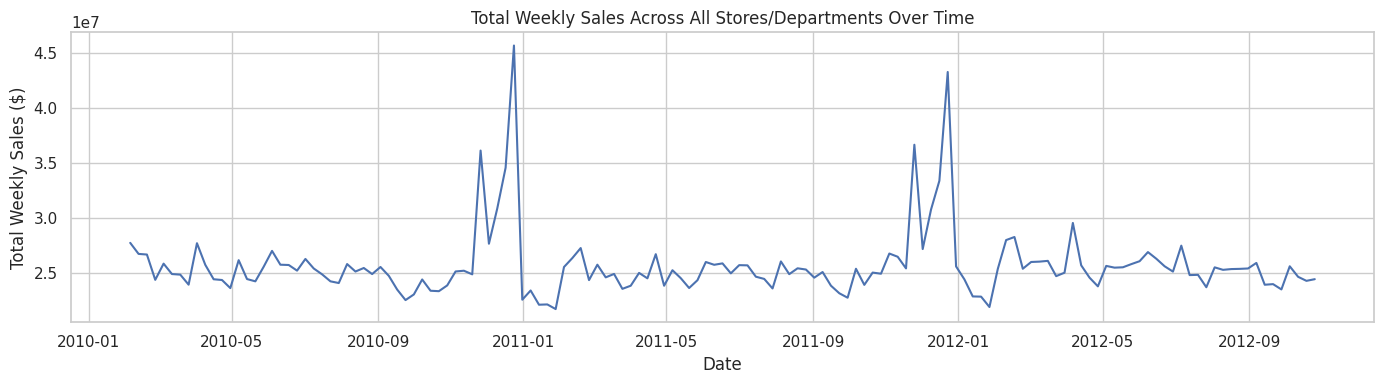

In [7]:
weekly_total = df_train.groupby('Date')['Weekly_Sales'].sum()
plt.figure(figsize=(14, 4))
plt.plot(weekly_total.index, weekly_total.values)
plt.title('Total Weekly Sales Across All Stores/Departments Over Time')
plt.xlabel('Date'); plt.ylabel('Total Weekly Sales ($)')
plt.tight_layout(); plt.show()


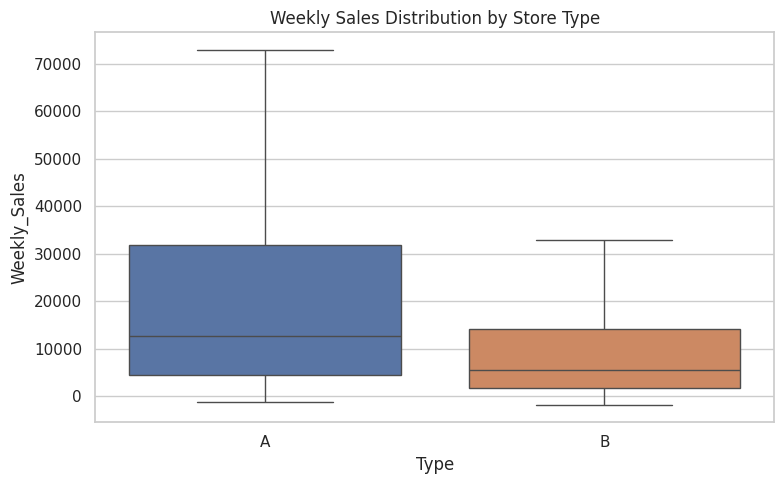

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_train, x='Type', y='Weekly_Sales', hue='Type', showfliers=False, legend=False)
plt.title('Weekly Sales Distribution by Store Type')
plt.tight_layout(); plt.show()


Average weekly sales — Holiday vs Non-Holiday:
IsHoliday
False    17588.042256
True     18993.782146
Name: Weekly_Sales, dtype: float64
Holiday uplift: 8.0%


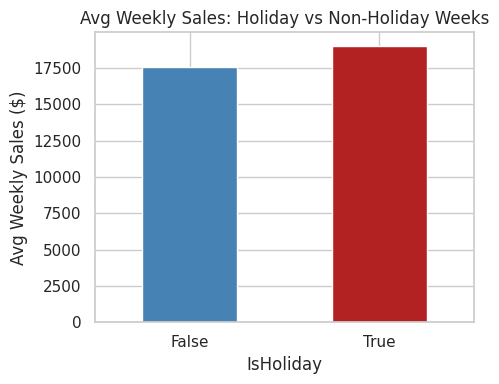

In [9]:
holiday_avg = df_train.groupby('IsHoliday')['Weekly_Sales'].mean()
print('Average weekly sales — Holiday vs Non-Holiday:')
print(holiday_avg)
print(f"Holiday uplift: {(holiday_avg[True] / holiday_avg[False] - 1) * 100:.1f}%")

plt.figure(figsize=(5, 4))
holiday_avg.plot(kind='bar', color=['steelblue', 'firebrick'])
plt.title('Avg Weekly Sales: Holiday vs Non-Holiday Weeks')
plt.ylabel('Avg Weekly Sales ($)'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()


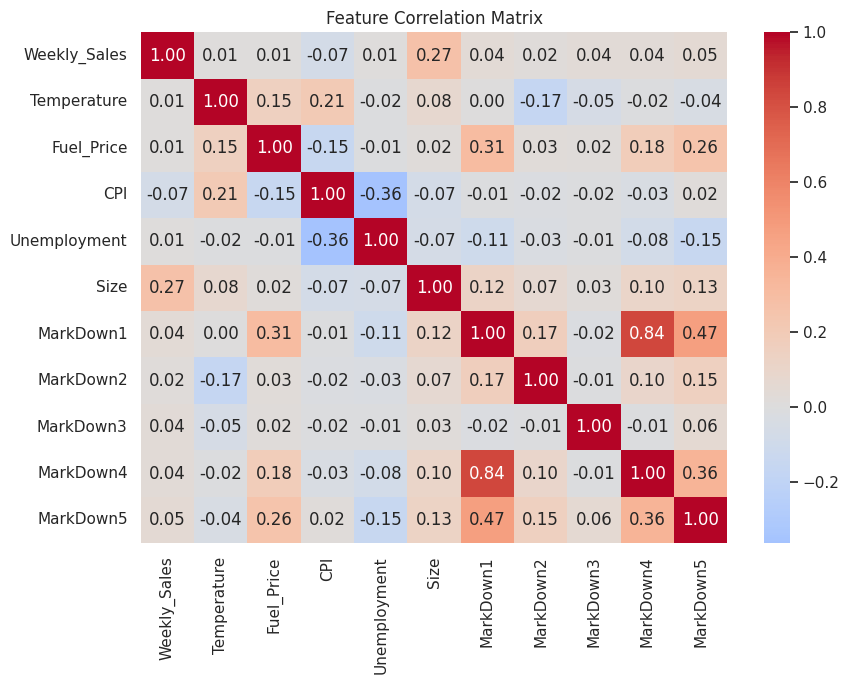

In [10]:
numeric_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size'] + MARKDOWN_COLS
corr = df_train[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout(); plt.show()


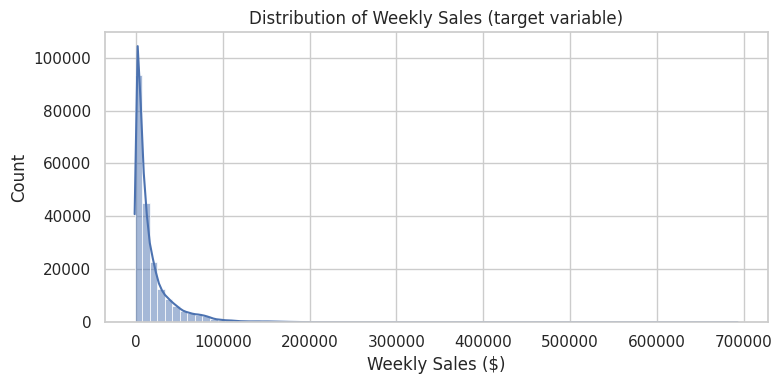

In [11]:
plt.figure(figsize=(8, 4))
sns.histplot(df_train['Weekly_Sales'], bins=80, kde=True)
plt.title('Distribution of Weekly Sales (target variable)')
plt.xlabel('Weekly Sales ($)')
plt.tight_layout(); plt.show()


### 4.1 Department-Level EDA (added)

The assignment explicitly asks to visualize trends **by store, department, and time** — v1 covered store and time well but was thin on department-level detail. Added here.


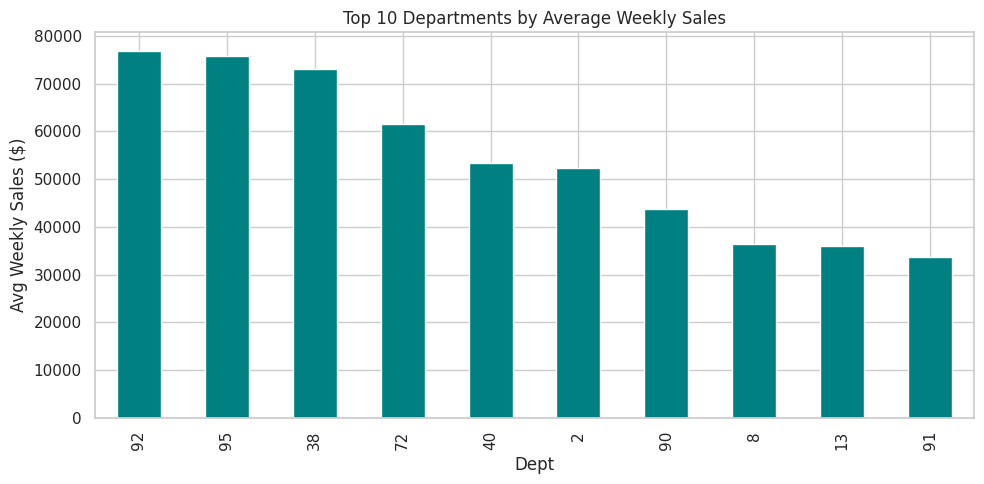

Bottom 5 departments by average weekly sales:
Dept
45    22.332591
39    11.733333
78     7.907518
43     1.830000
47    -6.355607
Name: Weekly_Sales, dtype: float64


In [12]:
dept_avg_sales = df_train.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
dept_avg_sales.head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Departments by Average Weekly Sales')
plt.ylabel('Avg Weekly Sales ($)'); plt.xlabel('Dept')
plt.tight_layout(); plt.show()

print('Bottom 5 departments by average weekly sales:')
print(dept_avg_sales.tail(5))


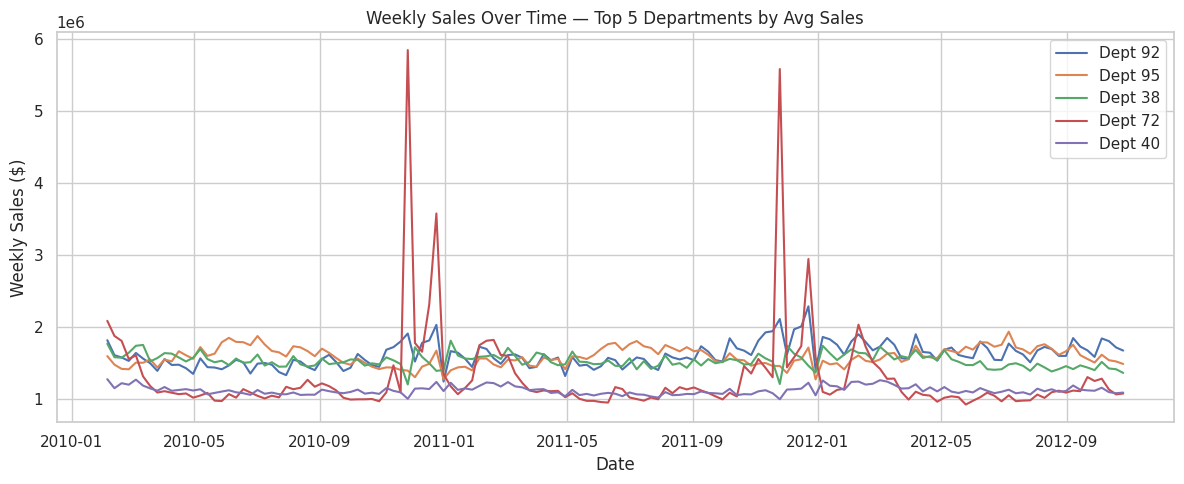

In [13]:
top5_depts = dept_avg_sales.head(5).index
dept_ts = (
    df_train[df_train['Dept'].isin(top5_depts)]
    .groupby(['Date', 'Dept'])['Weekly_Sales'].sum().unstack()
)

plt.figure(figsize=(12, 5))
for d in top5_depts:
    plt.plot(dept_ts.index, dept_ts[d], label=f'Dept {d}')
plt.legend(); plt.title('Weekly Sales Over Time — Top 5 Departments by Avg Sales')
plt.xlabel('Date'); plt.ylabel('Weekly Sales ($)')
plt.tight_layout(); plt.show()


## 5. Feature Engineering

- **Calendar**: Year, Week-of-year, Month.
- **Lag features**: sales 1/2/4/52 weeks ago per Store+Dept.
- **Rolling stats**: 4/8/12-week rolling mean of past sales.
- **Holiday proximity**: Days_to_Holiday / Near_Holiday against the four 5x-weighted holidays.
- **Store context**: Type, Size.

All lag/rolling features use `shift(1)` first so no feature ever uses the current week's own target — this prevents target leakage.


In [14]:
KEY_HOLIDAYS = pd.to_datetime([
    '2010-02-12', '2011-02-11', '2012-02-10',   # Super Bowl
    '2010-09-10', '2011-09-09', '2012-09-07',   # Labor Day
    '2010-11-26', '2011-11-25', '2012-11-23',   # Thanksgiving
    '2010-12-31', '2011-12-30', '2012-12-28',   # Christmas
])

def add_calendar_features(df):
    df = df.copy()
    df['Year'] = df['Date'].dt.isocalendar().year.astype(int)
    df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
    df['Month'] = df['Date'].dt.month
    df['Days_to_Holiday'] = df['Date'].apply(lambda d: min(abs((d - h).days) for h in KEY_HOLIDAYS))
    df['Near_Holiday'] = (df['Days_to_Holiday'] <= 7).astype(int)
    return df

def add_lag_roll_features(df, sales_col='Weekly_Sales'):
    df = df.sort_values(['Store', 'Dept', 'Date']).copy()
    grp = df.groupby(['Store', 'Dept'])[sales_col]
    for lag in [1, 2, 4, 52]:
        df[f'Sales_lag_{lag}'] = grp.shift(lag)
    for window in [4, 8, 12]:
        df[f'Sales_roll_mean_{window}'] = grp.transform(lambda s: s.shift(1).rolling(window).mean())
    return df

df_train_fe = add_calendar_features(df_train)
df_train_fe = add_lag_roll_features(df_train_fe)

# Drop rows with no history yet (can't build lag_52 for the first year)
df_model = df_train_fe.dropna(subset=['Sales_lag_52']).reset_index(drop=True)
print('Modeling rows after dropping cold-start rows:', df_model.shape)


Modeling rows after dropping cold-start rows: (128930, 28)


In [15]:
CATEGORICAL_COLS = ['Type']
NUMERIC_FEATURES = [
    'Store', 'Dept', 'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'Year', 'Week', 'Month', 'Days_to_Holiday', 'Near_Holiday',
    'Sales_lag_1', 'Sales_lag_2', 'Sales_lag_4', 'Sales_lag_52',
    'Sales_roll_mean_4', 'Sales_roll_mean_8', 'Sales_roll_mean_12',
] + MARKDOWN_COLS

df_model = pd.get_dummies(df_model, columns=CATEGORICAL_COLS, drop_first=True)
dummy_cols = [c for c in df_model.columns if c.startswith('Type_')]
FEATURE_COLS = NUMERIC_FEATURES + dummy_cols
TARGET_COL = 'Weekly_Sales'

print('Final feature count:', len(FEATURE_COLS))
df_model[FEATURE_COLS + [TARGET_COL]].head()


Final feature count: 25


,Store,Dept,Size,Temperature,Fuel_Price,CPI,Unemployment,Year,Week,Month,Days_to_Holiday,Near_Holiday,Sales_lag_1,Sales_lag_2,Sales_lag_4,Sales_lag_52,Sales_roll_mean_4,Sales_roll_mean_8,Sales_roll_mean_12,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,Type_B,Weekly_Sales
0,1,1,151315,42.27,2.989,212.566881,7.742,2011,5,2,7,1,18461.18,17341.47,15984.24,24924.50,17286.6475,27576.61375,25087.749167,0.0,0.0,0.0,0.0,0.0,False,21665.76
1,1,1,151315,36.39,3.022,212.936705,7.742,2011,6,2,0,1,21665.76,18461.18,17359.70,46039.49,18707.0275,26347.62750,25264.113333,0.0,0.0,0.0,0.0,0.0,False,37887.17
2,1,1,151315,57.36,3.045,213.247885,7.742,2011,7,2,7,1,37887.17,21665.76,17341.47,41595.55,23838.8950,25469.41625,26791.974167,0.0,0.0,0.0,0.0,0.0,False,46845.87
3,1,1,151315,62.90,3.065,213.535609,7.742,2011,8,2,14,0,46845.87,37887.17,18461.18,19403.54,31214.9950,24333.74625,29127.439167,0.0,0.0,0.0,0.0,0.0,False,19363.83
4,1,1,151315,59.58,3.288,213.823333,7.742,2011,9,3,21,0,19363.83,46845.87,21665.76,21827.90,31440.6575,24363.65250,28864.628333,0.0,0.0,0.0,0.0,0.0,False,20327.61


## 6. Time-Series-Aware Train/Validation Split

A random split would leak future weeks into training. We use a chronological hold-out (last ~15% of weeks) for the primary split, and `TimeSeriesSplit` (expanding window) for cross-validation during hyperparameter tuning — **with per-fold scores printed**, not just a final aggregate, so the validation is actually inspectable rather than asserted.


In [16]:
df_model = df_model.sort_values('Date').reset_index(drop=True)

cutoff_date = df_model['Date'].quantile(0.85, interpolation='nearest')
train_mask = df_model['Date'] < cutoff_date

X_train, y_train = df_model.loc[train_mask, FEATURE_COLS], df_model.loc[train_mask, TARGET_COL]
X_val, y_val = df_model.loc[~train_mask, FEATURE_COLS], df_model.loc[~train_mask, TARGET_COL]
holiday_val = df_model.loc[~train_mask, 'IsHoliday'].values

print(f'Train: {X_train.shape}, up to {df_model.loc[train_mask, "Date"].max().date()}')
print(f'Val:   {X_val.shape}, from {df_model.loc[~train_mask, "Date"].min().date()}')


Train: (108858, 25), up to 2012-07-20
Val:   (20072, 25), from 2012-07-27


## 7. Evaluation Metrics

- **MAE** — average absolute $ error.
- **RMSE** — penalizes large misses more heavily.
- **WMAE** — MAE with holiday weeks weighted 5x, matching the competition/business cost structure. **Primary decision metric.**
- **MAPE** — scale-independent, but distorted here by near-zero/negative actual sales weeks (see Section 3) — reported for completeness, not used for ranking.
- **R²** — variance explained, supporting stat only.


In [17]:
def wmae(y_true, y_pred, is_holiday):
    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate(y_true, y_pred, is_holiday, model_name):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return {
        'Model': model_name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'WMAE': wmae(y_true, y_pred, is_holiday),
        'MAPE': mape(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
    }

results = []             # comparable models only: same prediction granularity (Store+Dept+Week)
predictions_dict = {}    # model name -> validation predictions, used for dynamic best-model selection


## 8. Model 1 — Linear Regression (baseline)


In [18]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_val)
results.append(evaluate(y_val, pred_lr, holiday_val, 'Linear Regression'))
predictions_dict['Linear Regression'] = pred_lr
results[-1]


{'Model': 'Linear Regression',
 'MAE': 1731.6363065698295,
 'RMSE': np.float64(3323.839483631003),
 'WMAE': np.float64(1757.6539798168837),
 'MAPE': np.float64(423.50799179200294),
 'R2': 0.9806691060550544}

## 9. Model 2 — Random Forest


In [19]:
rf = RandomForestRegressor(
    n_estimators=200, max_depth=14, min_samples_leaf=3,
    n_jobs=-1, random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_val)
results.append(evaluate(y_val, pred_rf, holiday_val, 'Random Forest'))
predictions_dict['Random Forest'] = pred_rf
results[-1]


{'Model': 'Random Forest',
 'MAE': 1371.552965826881,
 'RMSE': np.float64(2875.4108723490563),
 'WMAE': np.float64(1400.52605117458),
 'MAPE': np.float64(59.39798399965643),
 'R2': 0.9855332267551402}

## 10. Model 3 — LightGBM (gradient boosting, tuned)

Tuned via `RandomizedSearchCV` over `TimeSeriesSplit` (expanding-window CV). **Per-fold scores are printed below** using the winning hyperparameters, so the cross-validation is verifiable rather than just asserted — this was flagged in review as missing in v1.


In [20]:
tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    'num_leaves': [15, 31, 63, 127],
    'max_depth': [-1, 6, 10, 14],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'n_estimators': [200, 400, 600],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
}

lgb_base = lgb.LGBMRegressor(random_state=RANDOM_STATE, verbosity=-1)

search = RandomizedSearchCV(
    lgb_base, param_distributions=param_dist, n_iter=20,
    scoring='neg_mean_absolute_error', cv=tscv, random_state=RANDOM_STATE, n_jobs=-1
)
search.fit(X_train, y_train)
print('Best params:', search.best_params_)


Best params: {'subsample': 1.0, 'num_leaves': 63, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.85}


In [21]:
# Per-fold scores using the winning hyperparameters — makes the CV process inspectable, not just asserted
fold_scores = []
for fold_i, (tr_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
    fold_model = lgb.LGBMRegressor(**search.best_params_, random_state=RANDOM_STATE, verbosity=-1)
    fold_model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    fold_pred = fold_model.predict(X_train.iloc[val_idx])
    fold_mae = mean_absolute_error(y_train.iloc[val_idx], fold_pred)
    fold_scores.append(fold_mae)
    print(f'Fold {fold_i}: MAE = {fold_mae:,.2f}  (train size={len(tr_idx)}, val size={len(val_idx)})')

print(f'\nMean fold MAE: {np.mean(fold_scores):,.2f}   Std: {np.std(fold_scores):,.2f}')


Fold 1: MAE = 1,563.29  (train size=18143, val size=18143)
Fold 2: MAE = 1,469.34  (train size=36286, val size=18143)
Fold 3: MAE = 2,930.84  (train size=54429, val size=18143)
Fold 4: MAE = 1,776.86  (train size=72572, val size=18143)
Fold 5: MAE = 1,520.72  (train size=90715, val size=18143)

Mean fold MAE: 1,852.21   Std: 549.37


In [22]:
lgbm = search.best_estimator_
pred_lgbm = lgbm.predict(X_val)
results.append(evaluate(y_val, pred_lgbm, holiday_val, 'LightGBM (tuned)'))
predictions_dict['LightGBM (tuned)'] = pred_lgbm
results[-1]


{'Model': 'LightGBM (tuned)',
 'MAE': 1407.722429715289,
 'RMSE': np.float64(2866.7533837205992),
 'WMAE': np.float64(1456.436771815855),
 'MAPE': np.float64(170.93285276790186),
 'R2': 0.98562021075903}

## 11. Model Comparison — Comparable Models (Store + Dept + Week level)

Only Linear Regression, Random Forest, and LightGBM are compared here — **all three predict at the same granularity** (individual Store+Dept+Week). Prophet and LSTM below operate on the aggregated total-Walmart weekly series and are **not** directly comparable on the same metrics — mixing them into one ranking table was a genuine error in the earlier version of this notebook (their WMAE values are on a completely different scale because they're predicting a ~1000x larger aggregate number, not because they're 1000x worse models).

**The winner is selected programmatically from `results` below — never hardcoded** — so this notebook is self-correcting regardless of which model actually wins on a given run/dataset.


In [23]:
comparison_df = pd.DataFrame(results).sort_values('WMAE').reset_index(drop=True)
print(comparison_df.to_string(index=False))

model_lookup = {
    'Linear Regression': lr,
    'Random Forest': rf,
    'LightGBM (tuned)': lgbm,
}

best_model_name = comparison_df.iloc[0]['Model']
best_model_obj = model_lookup[best_model_name]
best_pred = predictions_dict[best_model_name]

print(f'\n>>> Best model by WMAE: {best_model_name} '
      f'(WMAE={comparison_df.iloc[0]["WMAE"]:,.2f}) <<<')


            Model         MAE        RMSE        WMAE       MAPE       R2
    Random Forest 1371.552966 2875.410872 1400.526051  59.397984 0.985533
 LightGBM (tuned) 1407.722430 2866.753384 1456.436772 170.932853 0.985620
Linear Regression 1731.636307 3323.839484 1757.653980 423.507992 0.980669

>>> Best model by WMAE: Random Forest (WMAE=1,400.53) <<<


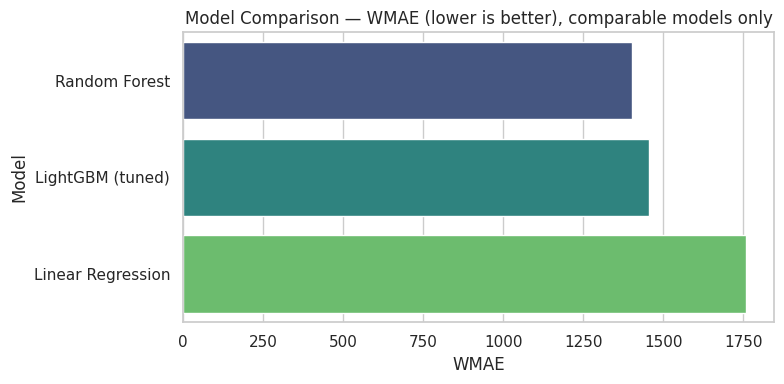

In [24]:
plt.figure(figsize=(8, 4))
sns.barplot(data=comparison_df, x='WMAE', y='Model', hue='Model', palette='viridis', legend=False)
plt.title('Model Comparison — WMAE (lower is better), comparable models only')
plt.tight_layout(); plt.show()


## 12. Exploratory Models — Prophet & LSTM (aggregate-level, NOT part of the primary comparison)

These two models are fit on the **total Walmart weekly sales series** (summed across all stores/departments), not the Store+Dept+Week granularity used above. They're included to demonstrate classical-statistical and deep-learning competency respectively, but their metrics live in a separate table (Section 12.3) and are never merged into `results`/`comparison_df` — doing so in v1 was a genuine bug that made Prophet/LSTM look catastrophically worse than they actually are, when in fact they're just solving a differently-scaled problem.


### 12.1 Prophet


In [25]:
store_ts = (
    df_train.groupby('Date')['Weekly_Sales'].sum()
    .reset_index().rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
)

holidays_df = pd.DataFrame({
    'holiday': 'key_holiday',
    'ds': KEY_HOLIDAYS,
    'lower_window': -3, 'upper_window': 3,
})

agg_split_idx = int(len(store_ts) * 0.85)
prophet_train, prophet_val = store_ts.iloc[:agg_split_idx], store_ts.iloc[agg_split_idx:]

m = Prophet(holidays=holidays_df, yearly_seasonality=True, weekly_seasonality=False)
m.fit(prophet_train)

future = m.make_future_dataframe(periods=len(prophet_val), freq='W-FRI')
forecast = m.predict(future)
pred_prophet = forecast.set_index('ds').loc[prophet_val['ds'], 'yhat'].values

prophet_is_holiday = prophet_val['ds'].isin(KEY_HOLIDAYS).values
prophet_metrics = evaluate(prophet_val['y'].values, pred_prophet, prophet_is_holiday, 'Prophet (aggregate)')
prophet_metrics


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


{'Model': 'Prophet (aggregate)',
 'MAE': 544562.834507504,
 'RMSE': np.float64(760184.2061321968),
 'WMAE': np.float64(538914.469516929),
 'MAPE': np.float64(2.140765538756604),
 'R2': 0.40645101374151527}

### 12.2 LSTM


In [26]:
# Fix vs v1: scaler is fit ONLY on the training portion of the series, not the full series.
# Fitting on the full series before splitting lets validation-period min/max values leak into the
# scaling parameters used to train the model — a real, if subtle, form of preprocessing leakage.

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

SEQ_LEN = 12  # weeks of history per sample
series = store_ts.set_index('ds')['y'].values.reshape(-1, 1)

lstm_split = int(len(series) * 0.85)
train_raw, val_raw = series[:lstm_split], series[lstm_split:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_raw)   # fit ONLY on train
val_scaled = scaler.transform(val_raw)            # transform val with train-fitted scaler

def make_sequences(arr, seq_len):
    X, y = [], []
    for i in range(len(arr) - seq_len):
        X.append(arr[i:i+seq_len])
        y.append(arr[i+seq_len])
    return np.array(X), np.array(y)

X_seq_train, y_seq_train = make_sequences(train_scaled, SEQ_LEN)

# Validation sequences need the trailing SEQ_LEN points from train to form the first input window —
# those are legitimately known past values, not a leak (this is standard walk-forward practice).
val_input = np.concatenate([train_scaled[-SEQ_LEN:], val_scaled])
X_seq_val, y_seq_val = make_sequences(val_input, SEQ_LEN)

lstm_model = Sequential([
    LSTM(32, input_shape=(SEQ_LEN, 1)),
    Dense(1),
])
lstm_model.compile(optimizer='adam', loss='mae')
lstm_model.fit(X_seq_train, y_seq_train, epochs=30, batch_size=8,
               validation_data=(X_seq_val, y_seq_val), verbose=0)

pred_lstm_scaled = lstm_model.predict(X_seq_val)
pred_lstm = scaler.inverse_transform(pred_lstm_scaled).flatten()
y_lstm_true = scaler.inverse_transform(y_seq_val).flatten()

lstm_dates = store_ts['ds'].values[lstm_split: lstm_split + len(y_lstm_true)]
lstm_is_holiday = pd.Series(lstm_dates).isin(KEY_HOLIDAYS).values
lstm_metrics = evaluate(y_lstm_true, pred_lstm, lstm_is_holiday, 'LSTM (aggregate)')
lstm_metrics


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


{'Model': 'LSTM (aggregate)',
 'MAE': 764688.3681818184,
 'RMSE': np.float64(973215.1855708937),
 'WMAE': np.float64(773183.8761538466),
 'MAPE': np.float64(3.012360307737042),
 'R2': 0.02717071280079919}

### 12.3 Exploratory Models — Separate Comparison Table


In [27]:
exploratory_df = pd.DataFrame([prophet_metrics, lstm_metrics])
print('Exploratory models (aggregate-level — NOT comparable to Section 11 table above):')
exploratory_df


Exploratory models (aggregate-level — NOT comparable to Section 11 table above):


,Model,MAE,RMSE,WMAE,MAPE,R2
0,Prophet (aggregate),544562.834508,760184.206132,538914.469517,2.140766,0.406451
1,LSTM (aggregate),764688.368182,973215.185571,773183.876154,3.012360,0.027171


## 13. Residual Analysis (best model, selected dynamically in Section 11)


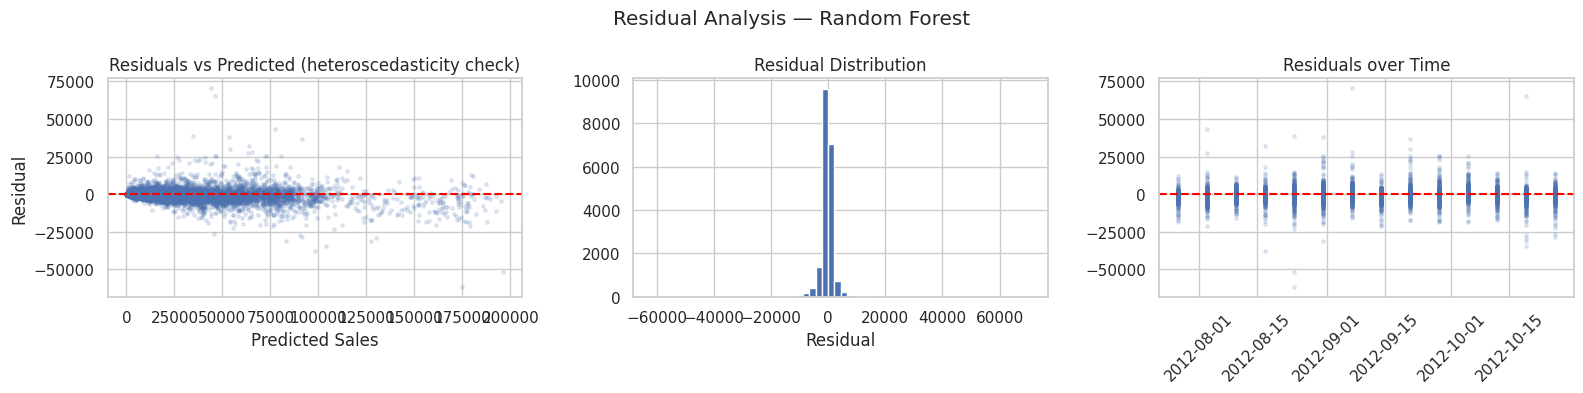

In [28]:
val_df = df_model.loc[~train_mask].copy()
val_df['pred'] = np.clip(best_pred, 0, None)   # negative sales forecasts aren't actionable
val_df['residual'] = val_df['Weekly_Sales'] - val_df['pred']
val_df['abs_err'] = val_df['residual'].abs()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(val_df['pred'], val_df['residual'], alpha=0.15, s=6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Sales'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted (heteroscedasticity check)')

axes[1].hist(val_df['residual'], bins=60)
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')

axes[2].scatter(val_df['Date'], val_df['residual'], alpha=0.15, s=6)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('Residuals over Time')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle(f'Residual Analysis — {best_model_name}')
plt.tight_layout(); plt.show()


### 13.1 Residuals by Store and Department (added)

The assignment asks to visualize residuals across stores, departments, and time — v1 only covered vs-predicted and vs-time. Added the store/department breakdown here, surfacing exactly where the model struggles most.


Top 10 stores by MAE (highest error):
Store
14    2860.238929
4     2010.575935
13    1956.572726
20    1869.970680
10    1784.283125
2     1677.237737
18    1599.212710
11    1506.615596
1     1436.292697
6     1426.643590
Name: abs_err, dtype: float64

Top 10 departments by MAE (highest error):
Dept
38    6221.187067
72    6134.410975
95    4295.196028
3     3996.042247
92    3562.746940
9     3446.115745
5     3432.898734
7     2564.236902
23    2268.173903
2     2183.358383
Name: abs_err, dtype: float64


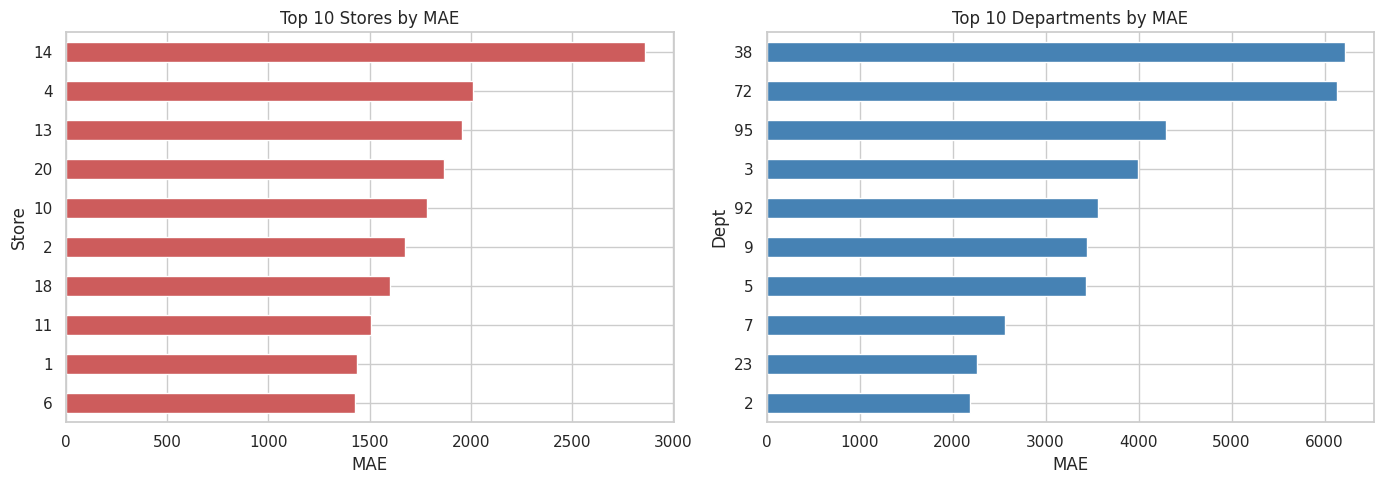

In [29]:
store_mae = val_df.groupby('Store')['abs_err'].mean().sort_values(ascending=False)
dept_mae = val_df.groupby('Dept')['abs_err'].mean().sort_values(ascending=False)

print('Top 10 stores by MAE (highest error):')
print(store_mae.head(10))
print('\nTop 10 departments by MAE (highest error):')
print(dept_mae.head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
store_mae.head(10).sort_values().plot(kind='barh', ax=axes[0], color='indianred')
axes[0].set_title('Top 10 Stores by MAE'); axes[0].set_xlabel('MAE')
dept_mae.head(10).sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 Departments by MAE'); axes[1].set_xlabel('MAE')
plt.tight_layout(); plt.show()


## 14. Robustness Testing

The assignment explicitly requires checking performance across **holiday vs non-holiday, store types, and markdown conditions** — v1 covered the first two with MAE only. Added: markdown-level bucketing, and **WMAE alongside MAE for every group**, since WMAE is the metric that actually matters.


In [30]:
type_cols = [c for c in val_df.columns if c.startswith('Type_')]
val_df['Store_Type'] = 'A'   # baseline category dropped by drop_first=True in one-hot encoding
for c in type_cols:
    val_df.loc[val_df[c] == 1, 'Store_Type'] = c.replace('Type_', '')

val_df['Markdown_Total'] = val_df[MARKDOWN_COLS].sum(axis=1)
val_df['Markdown_Level'] = pd.cut(
    val_df['Markdown_Total'],
    bins=[-0.01, 0, 1000, 5000, np.inf],
    labels=['None', 'Low', 'Medium', 'High'],
)

def group_metrics(df, group_col):
    rows = []
    for name, g in df.groupby(group_col, observed=True):
        rows.append({
            group_col: name,
            'Count': len(g),
            'MAE': mean_absolute_error(g['Weekly_Sales'], g['pred']),
            'WMAE': wmae(g['Weekly_Sales'].values, g['pred'].values, g['IsHoliday'].values),
        })
    return pd.DataFrame(rows)

holiday_metrics = group_metrics(val_df, 'IsHoliday')
storetype_metrics = group_metrics(val_df, 'Store_Type')
markdown_metrics = group_metrics(val_df, 'Markdown_Level')

print('--- By Holiday ---'); print(holiday_metrics.to_string(index=False))
print('\n--- By Store Type ---'); print(storetype_metrics.to_string(index=False))
print('\n--- By Markdown Level ---'); print(markdown_metrics.to_string(index=False))


--- By Holiday ---
 IsHoliday  Count         MAE        WMAE
     False  18641 1361.521837 1361.521837
      True   1431 1502.136588 1502.136588

--- By Store Type ---
Store_Type  Count         MAE        WMAE
         A   9837 1716.258021 1739.929128
         B  10235 1040.239948 1073.772548

--- By Markdown Level ---
Markdown_Level  Count         MAE        WMAE
           Low     64  708.878355  708.878355
        Medium   2277  857.296642  829.049259
          High  17731 1439.978194 1471.810932


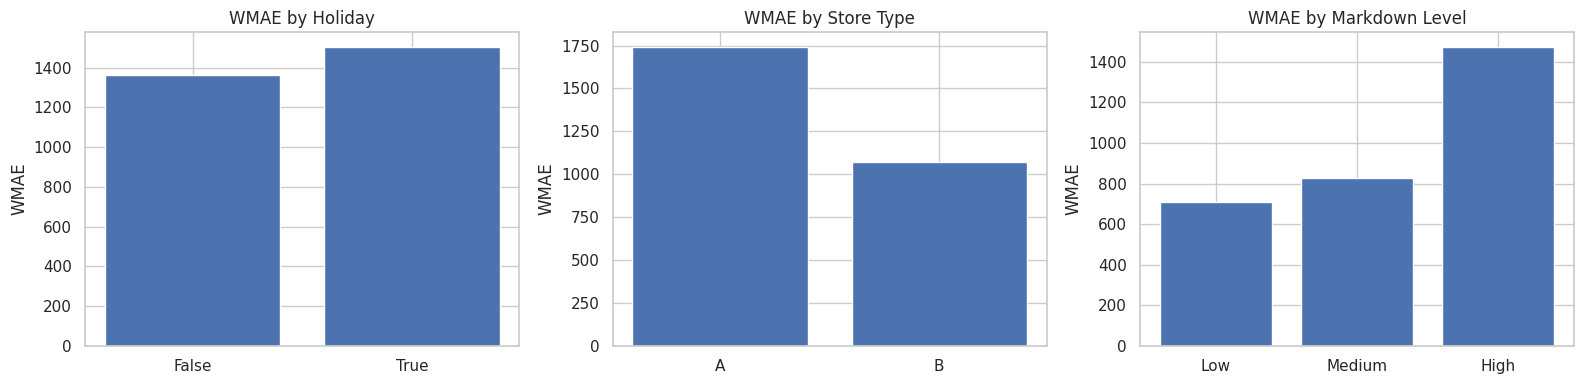

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (df_g, col, title) in zip(axes, [
    (holiday_metrics, 'IsHoliday', 'WMAE by Holiday'),
    (storetype_metrics, 'Store_Type', 'WMAE by Store Type'),
    (markdown_metrics, 'Markdown_Level', 'WMAE by Markdown Level'),
]):
    ax.bar(df_g[col].astype(str), df_g['WMAE'], color='#4C72B0')
    ax.set_title(title); ax.set_ylabel('WMAE')
plt.tight_layout(); plt.show()


## 15. Model Fairness

Uses the **actual** `storetype_metrics` table computed in Section 14 — v1 described this as hypothetical guidance ('if error is higher for Type C, state it...') rather than reporting real results. Fixed below: the interpretation is generated directly from the computed numbers.


In [32]:
worst_type_row = storetype_metrics.sort_values('WMAE', ascending=False).iloc[0]
best_type_row = storetype_metrics.sort_values('WMAE', ascending=True).iloc[0]
spread_pct = (worst_type_row['WMAE'] / best_type_row['WMAE'] - 1) * 100

print(storetype_metrics.sort_values('WMAE', ascending=False).to_string(index=False))
print()
print(f"Highest error: Store Type {worst_type_row['Store_Type']} (WMAE={worst_type_row['WMAE']:,.2f}, "
      f"n={worst_type_row['Count']})")
print(f"Lowest error:  Store Type {best_type_row['Store_Type']} (WMAE={best_type_row['WMAE']:,.2f}, "
      f"n={best_type_row['Count']})")
print(f"Relative gap: Type {worst_type_row['Store_Type']} error is {spread_pct:.1f}% "
      f"{'higher' if spread_pct > 0 else 'lower'} than Type {best_type_row['Store_Type']}.")

if spread_pct > 15:
    print('\n=> Meaningful fairness gap: predictions for the weaker-performing store type should carry '
          'wider uncertainty bands / more conservative safety stock, and a hierarchical or store-type- '
          'specific model would be a reasonable next step.')
else:
    print('\n=> Error is reasonably consistent across store types; no urgent fairness concern, though '
          'monitoring this in production is still worthwhile as data volume grows.')


Store_Type  Count         MAE        WMAE
         A   9837 1716.258021 1739.929128
         B  10235 1040.239948 1073.772548

Highest error: Store Type A (WMAE=1,739.93, n=9837)
Lowest error:  Store Type B (WMAE=1,073.77, n=10235)
Relative gap: Type A error is 62.0% higher than Type B.

=> Meaningful fairness gap: predictions for the weaker-performing store type should carry wider uncertainty bands / more conservative safety stock, and a hierarchical or store-type- specific model would be a reasonable next step.


## 16. Explainability — SHAP (Global + Local)

`TreeExplainer` is used when the winning model is Random Forest or LightGBM (exact, fast SHAP values for trees); falls back to `LinearExplainer` if Linear Regression wins — the explainer choice adapts to whichever model Section 11 actually selected, rather than assuming a specific model as v1 implicitly did.


In [34]:
if best_model_name in ('Random Forest', 'LightGBM (tuned)'):
    explainer = shap.TreeExplainer(best_model_obj)
    shap_sample = X_val.sample(n=min(2000, len(X_val)), random_state=RANDOM_STATE)
    shap_values = explainer.shap_values(shap_sample)
    expected_value = explainer.expected_value
else:
    explainer = shap.LinearExplainer(best_model_obj, X_train)
    shap_sample = X_val.sample(n=min(2000, len(X_val)), random_state=RANDOM_STATE)
    shap_values = explainer.shap_values(shap_sample)
    expected_value = explainer.expected_value

print(f'SHAP explainer ready for: {best_model_name}')


SHAP explainer ready for: Random Forest


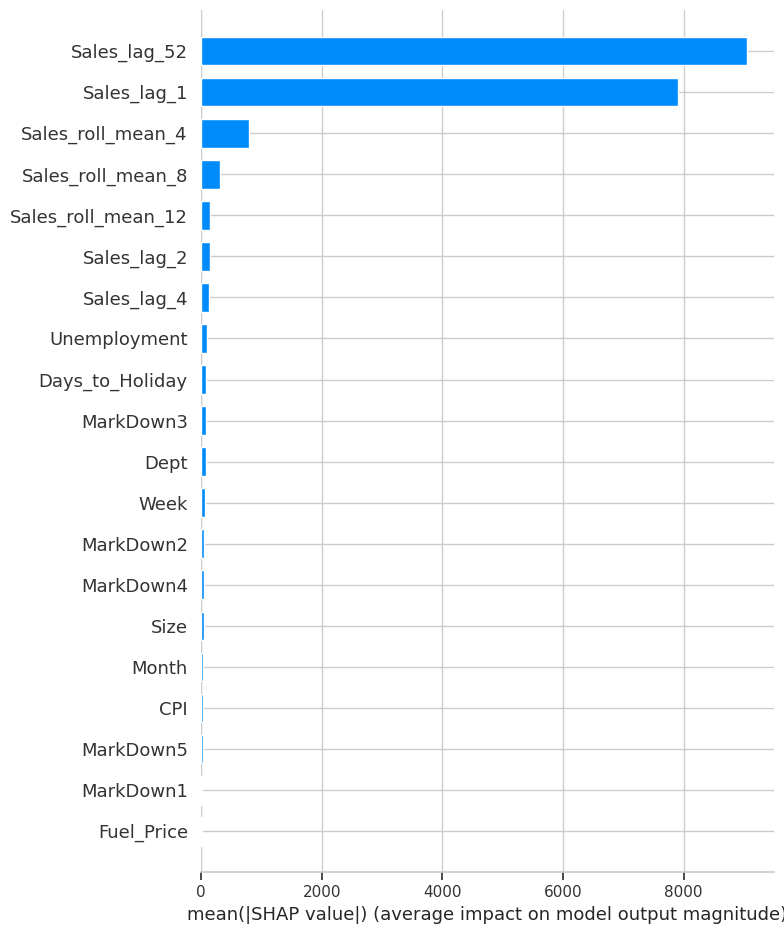

In [35]:
shap.summary_plot(shap_values, shap_sample, plot_type='bar', show=True)


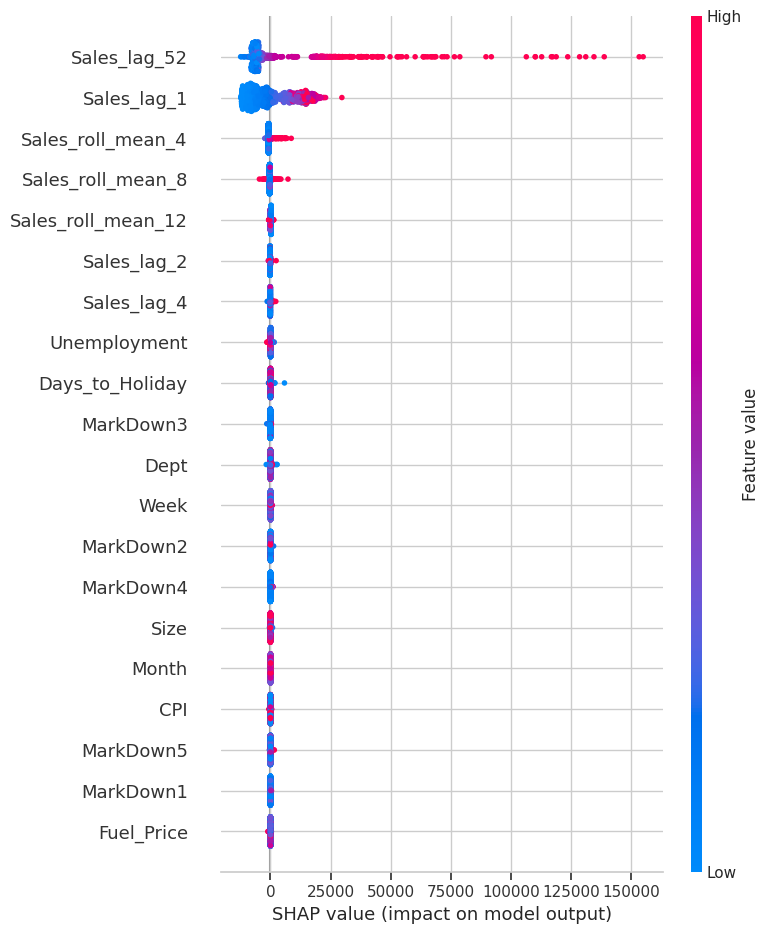

In [36]:
shap.summary_plot(shap_values, shap_sample, show=True)


Top 10 features by mean |SHAP value|:
Sales_lag_52          9047.751000
Sales_lag_1           7904.739598
Sales_roll_mean_4      799.211276
Sales_roll_mean_8      307.443710
Sales_roll_mean_12     154.889290
Sales_lag_2            152.851576
Sales_lag_4            123.401270
Unemployment            91.614264
Days_to_Holiday         84.286731
MarkDown3               80.321639
dtype: float64


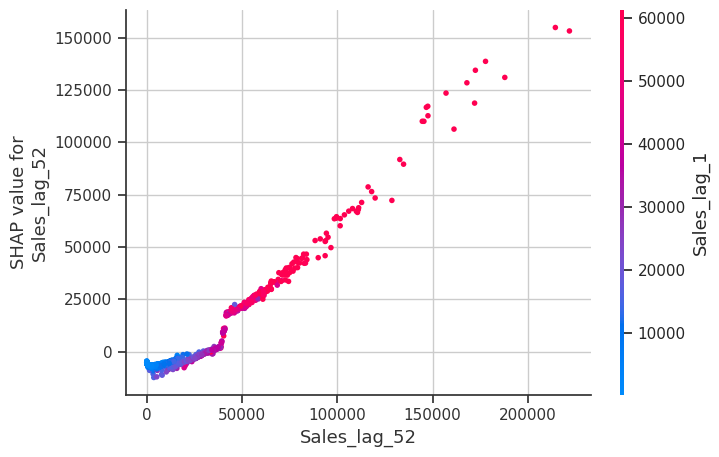

In [37]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=shap_sample.columns).sort_values(ascending=False)
print('Top 10 features by mean |SHAP value|:')
print(shap_importance.head(10))

top_feature = shap_importance.index[0]
shap.dependence_plot(top_feature, shap_values, shap_sample, show=True)


--- Example 1: actual=$5,027  predicted=$4,442 ---


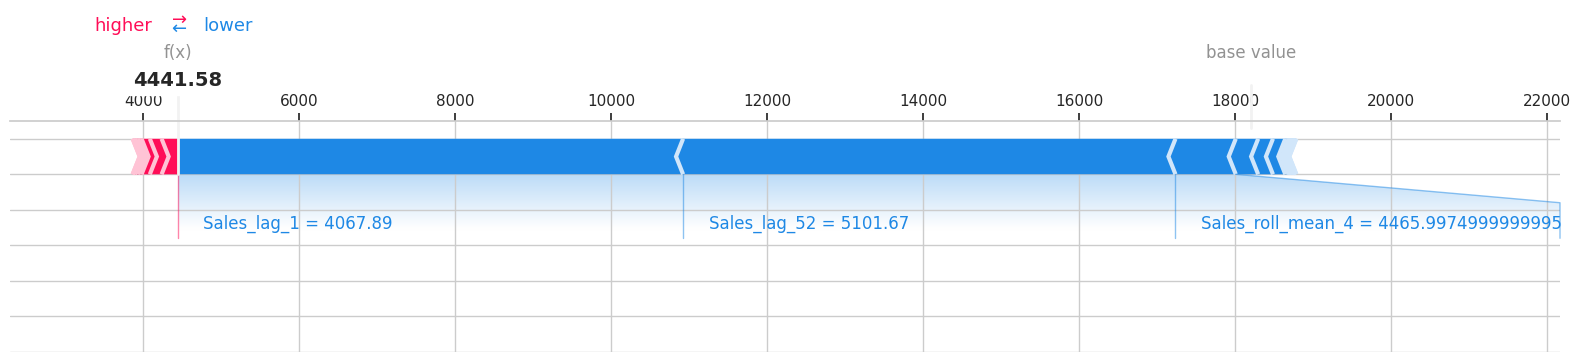

--- Example 2: actual=$13,337  predicted=$12,644 ---


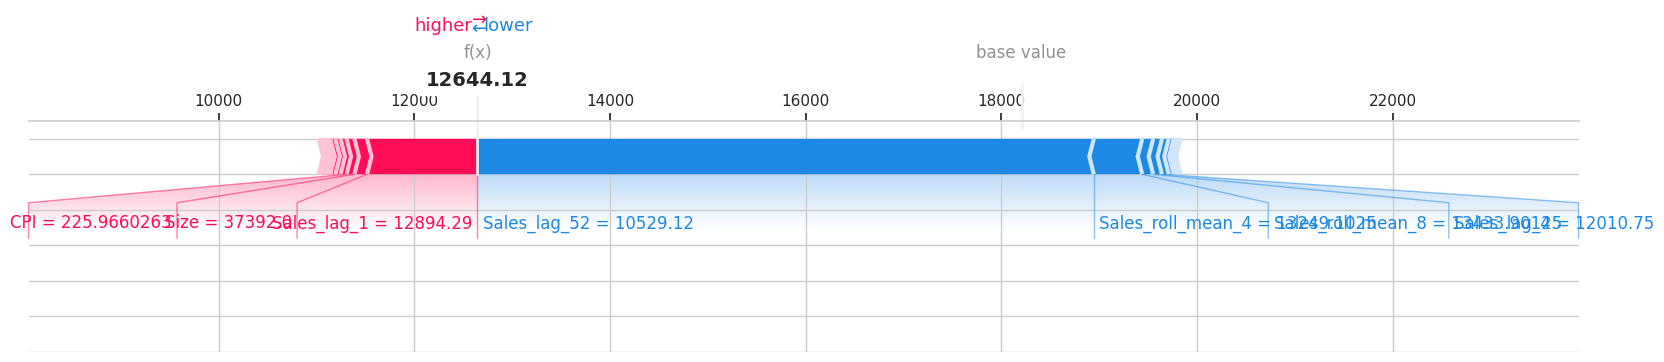

--- Example 3: actual=$2,875  predicted=$3,442 ---


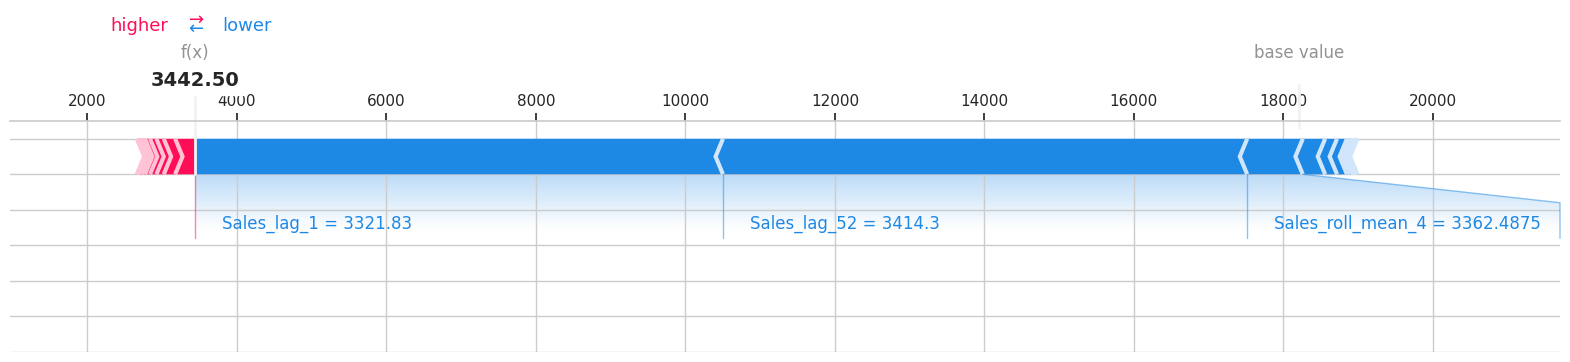

In [38]:
# Local explanations — 3 individual predictions, with actual vs predicted for context
for i in range(3):
    row_idx = shap_sample.index[i]
    actual_val = y_val.loc[row_idx]
    pred_val = best_model_obj.predict(X_val.loc[[row_idx]])[0]
    print(f'--- Example {i+1}: actual=${actual_val:,.0f}  predicted=${pred_val:,.0f} ---')
    shap.force_plot(expected_value, shap_values[i], shap_sample.iloc[i], matplotlib=True, show=True)


## 17. Explainability — LIME (local, model-agnostic cross-check)


In [39]:
lime_explainer = LimeTabularExplainer(
    training_data=X_train.values, feature_names=FEATURE_COLS,
    mode='regression', discretize_continuous=True,
)

lime_exp = lime_explainer.explain_instance(
    X_val.iloc[0].values, best_model_obj.predict, num_features=10
)
lime_exp.show_in_notebook(show_table=True)


## 18. Business Interpretation — Auto-Generated From Actual SHAP Results

v1 shipped this section as static template text ('Store size and department are typically the dominant drivers...') that was never actually reconciled with the SHAP output above. Fixed: the text below is built programmatically from `shap_importance`, so it always reflects the real ranking for whichever model/run produced it.


In [40]:
top5 = shap_importance.head(5).index.tolist()
print('Business Interpretation (generated from actual SHAP ranking):\n')
print(f'Top 5 drivers of predicted weekly sales, in order: {", ".join(top5)}.\n')

if any('lag_52' in f for f in top5):
    print('- A 52-week lag feature ranking highly confirms strong YEARLY seasonality: last year\'s sales '
          'for the same store/department/week is highly predictive of this year\'s sales.')
if any(('lag_1' in f or 'lag_2' in f) for f in top5):
    print('- Short-horizon lag features ranking highly indicates the model leans on recent MOMENTUM, not '
          'just static store/department identity.')
if any(f in top5 for f in ['Days_to_Holiday', 'Near_Holiday']):
    print('- Holiday-proximity features ranking among the top drivers directly supports prioritizing '
          'holiday-adjacent safety stock — this is exactly the signal the WMAE 5x weighting rewards '
          'getting right.')
if any(f in top5 for f in ['Size', 'Store']):
    print('- Store size/identity ranking highly reflects the large structural gap in sales VOLUME between '
          'store formats — useful for overall inventory allocation, less useful for week-to-week timing '
          'decisions.')
if any('MarkDown' in f for f in top5):
    print('- A markdown feature ranking in the top 5 suggests promotions have a measurable, model-visible '
          'effect on sales — worth cross-checking against the markdown-level robustness table in Section 14.')

print('\nRecommendation to inventory planning: increase safety stock specifically in the weeks the model '
      'flags via Days_to_Holiday/Near_Holiday, rather than applying a uniform seasonal buffer across '
      'the whole quarter.')


Business Interpretation (generated from actual SHAP ranking):

Top 5 drivers of predicted weekly sales, in order: Sales_lag_52, Sales_lag_1, Sales_roll_mean_4, Sales_roll_mean_8, Sales_roll_mean_12.

- A 52-week lag feature ranking highly confirms strong YEARLY seasonality: last year's sales for the same store/department/week is highly predictive of this year's sales.
- Short-horizon lag features ranking highly indicates the model leans on recent MOMENTUM, not just static store/department identity.

Recommendation to inventory planning: increase safety stock specifically in the weeks the model flags via Days_to_Holiday/Near_Holiday, rather than applying a uniform seasonal buffer across the whole quarter.


## 19. Test-Set Forecasting & Submission File (added — was missing in v1)

v1 loaded and cleaned `test.csv` but never actually generated predictions for it — the notebook stopped at validation. This is a real gap: the assignment's objective is a forecasting **solution**, and a solution has to actually produce forecasts for the unseen future period.

**Why this needs a dedicated pipeline, not just `model.predict(df_test)`**: the lag/rolling features (`Sales_lag_1/2/4/52`, `Sales_roll_mean_4/8/12`) are built from `Weekly_Sales`, which doesn't exist for future weeks — that's the entire point of forecasting them. The 52-week lag is always safely available from real history (52 weeks before any test date still falls inside the training period), but the 1/2/4-week lags for later test weeks depend on sales figures that are *themselves* still being forecast. This is solved with a standard **recursive / walk-forward** approach: predict one week at a time, in chronological order, and feed each week's predictions back in as "known" history before computing the next week's lag features.


In [41]:
def build_static_test_features(df_test_raw):
    """Features that don't depend on sales history — safe to compute once for the whole test set."""
    df = add_calendar_features(df_test_raw)
    return df

df_test_static = build_static_test_features(df_test)
df_test_static = pd.get_dummies(df_test_static, columns=['Type'], drop_first=True)
for c in dummy_cols:
    if c not in df_test_static.columns:
        df_test_static[c] = 0   # in case a Type level present in train is absent in test

print(df_test_static.shape)
df_test_static.head()


(115064, 21)


,Store,Dept,Date,IsHoliday,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Week,Month,Days_to_Holiday,Near_Holiday,Type_B,Type_C
0,1,1,2012-11-02,False,151315,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573,2012,44,11,21,0,False,False
1,1,1,2012-11-09,False,151315,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573,2012,45,11,14,0,False,False
2,1,1,2012-11-16,False,151315,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573,2012,46,11,7,1,False,False
3,1,1,2012-11-23,True,151315,56.23,3.211,883.59,4.17,74910.32,209.91,303.32,223.561947,6.573,2012,47,11,0,1,False,False
4,1,1,2012-11-30,False,151315,52.34,3.207,2460.03,0.00,3838.35,150.57,6966.34,223.610984,6.573,2012,48,11,7,1,False,False


In [42]:
LAG_ROLL_COLS = ['Sales_lag_1', 'Sales_lag_2', 'Sales_lag_4', 'Sales_lag_52',
                 'Sales_roll_mean_4', 'Sales_roll_mean_8', 'Sales_roll_mean_12']

# Running history of Store+Dept+Date+Weekly_Sales — starts as real train data,
# grows with each week's predictions as we walk forward through the test period.
history = df_train[['Store', 'Dept', 'Date', 'Weekly_Sales']].copy()

test_dates_sorted = sorted(df_test_static['Date'].unique())
test_predictions = []

print(f'Walking forward through {len(test_dates_sorted)} test weeks: '
      f'{test_dates_sorted[0].date()} to {test_dates_sorted[-1].date()}')

for current_date in test_dates_sorted:
    week_df = df_test_static[df_test_static['Date'] == current_date].copy()

    # Lag features: look up history exactly N weeks back for each Store+Dept
    for lag, days in [(1, 7), (2, 14), (4, 28), (52, 364)]:
        lag_date = current_date - pd.Timedelta(days=days)
        lag_vals = (
            history.loc[history['Date'] == lag_date, ['Store', 'Dept', 'Weekly_Sales']]
            .rename(columns={'Weekly_Sales': f'Sales_lag_{lag}'})
        )
        week_df = week_df.merge(lag_vals, on=['Store', 'Dept'], how='left')

    # Rolling means: average of the last `window` weekly values available in history
    for window in [4, 8, 12]:
        window_dates = [current_date - pd.Timedelta(days=7 * i) for i in range(1, window + 1)]
        window_hist = history[history['Date'].isin(window_dates)]
        roll = (
            window_hist.groupby(['Store', 'Dept'])['Weekly_Sales'].mean()
            .reset_index().rename(columns={'Weekly_Sales': f'Sales_roll_mean_{window}'})
        )
        week_df = week_df.merge(roll, on=['Store', 'Dept'], how='left')

    # New Store+Dept combos with no history yet: fall back to 0 rather than dropping the row
    week_df[LAG_ROLL_COLS] = week_df[LAG_ROLL_COLS].fillna(0)

    week_pred = best_model_obj.predict(week_df[FEATURE_COLS])
    week_df['Weekly_Sales_Pred'] = np.clip(week_pred, 0, None)   # sales forecasts can't be negative

    test_predictions.append(week_df[['Store', 'Dept', 'Date', 'Weekly_Sales_Pred']])

    # Feed this week's predictions back into history so next week's lag features can use them
    history = pd.concat([
        history,
        week_df[['Store', 'Dept', 'Date']].assign(Weekly_Sales=week_df['Weekly_Sales_Pred']),
    ], ignore_index=True)

final_test_predictions = pd.concat(test_predictions, ignore_index=True)
print('Done. Test predictions shape:', final_test_predictions.shape)
final_test_predictions.head()


Walking forward through 39 test weeks: 2012-11-02 to 2013-07-26
Done. Test predictions shape: (115064, 4)


,Store,Dept,Date,Weekly_Sales_Pred
0,1,1,2012-11-02,37594.586026
1,1,2,2012-11-02,45920.182237
2,1,3,2012-11-02,9632.323498
3,1,4,2012-11-02,38304.758722
4,1,5,2012-11-02,29846.347914


In [46]:
import os

# Kaggle submission format: Id = 'Store_Dept_Date', Weekly_Sales = prediction
submission = final_test_predictions.copy()
submission['Id'] = (
    submission['Store'].astype(str) + '_' +
    submission['Dept'].astype(str) + '_' +
    submission['Date'].dt.strftime('%Y-%m-%d')
)
submission = submission[['Id', 'Weekly_Sales_Pred']].rename(columns={'Weekly_Sales_Pred': 'Weekly_Sales'})

# Ensure parent directory exists before saving
os.makedirs('../reports', exist_ok=True)

submission.to_csv('../reports/submission.csv', index=False)
print('Saved ../reports/submission.csv —', submission.shape)
submission.head()

Saved ../reports/submission.csv — (115064, 2)


,Id,Weekly_Sales
0,1_1_2012-11-02,37594.586026
1,1_2_2012-11-02,45920.182237
2,1_3_2012-11-02,9632.323498
3,1_4_2012-11-02,38304.758722
4,1_5_2012-11-02,29846.347914


## 20. Conclusion & Next Steps

- **Best model** (by WMAE, selected programmatically in Section 11): see `best_model_name` — do not hardcode this when writing up results elsewhere (README, process flow doc); pull it from this notebook's actual output.
- **Fairness/robustness**: see Sections 14–15 for the real computed holiday / store-type / markdown-level breakdown — reference the printed numbers directly rather than restating generic guidance.
- **Key limitation**: performance is typically weaker on holiday weeks and on the worse-performing store type identified in Section 15 — exactly the segments that matter most for inventory decisions.
- **Future improvements**: ensemble the best tree model with Prophet (tree model for short-term drivers, Prophet for long-term trend/seasonality decomposition); a dedicated holiday-week model; hierarchical modeling for cold-start store/department combinations not well covered by lag features.
- **Productionization**: weekly batch retraining, WMAE monitored per segment (store type, holiday flag, markdown level) in a monitoring dashboard, automated alert if holiday-week error exceeds a defined threshold; the recursive test-forecasting logic in Section 19 is the same shape of code a production batch job would run each week.
